# 02. 전처리 — 학습셋 v8 만들기

01에서 확인한 데이터를 모델이 먹을 수 있는 형태로 바꾼다.

이 노트북에서 다루는 것
1. **생년 교정** — FA 원본의 생년이 틀려 나이 피처가 오염돼 있었다
2. **3년 집계 피처** — FA 직전 3시즌을 하나의 행으로
3. **스타성 피처** — MVP·골든글러브·국가대표 수상 이력
4. **범주형 인코딩** — 투수 역할(선발/셋업/마무리)을 숫자로
5. **리그 대비 백분위** — 같은 스탯도 그 해 리그 수준에 따라 값어치가 다르다
6. **데이터 누수 컬럼 제외**

## 0. 환경 설정

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA = ROOT / "data"
CHARTS = ROOT / "output" / "charts" / "notebook"
CHARTS.mkdir(parents=True, exist_ok=True)

# 순서 주의: seaborn의 set_style이 font.family를 sans-serif로 되돌린다.
# 폰트를 먼저 잡고 스타일을 나중에 걸면 한글이 전부 네모로 깨진다.
sns.set_style("whitegrid")

try:
    import koreanize_matplotlib  # noqa: F401
except ImportError:
    from matplotlib import font_manager
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for candidate in ("NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"):
        if candidate in installed:
            plt.rcParams["font.family"] = candidate
            plt.rcParams["font.sans-serif"] = [candidate]
            break
    else:
        print("경고: 한글 폰트를 못 찾았다. 라벨이 네모로 나올 수 있다.")

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

print("루트:", ROOT)
print("폰트:", plt.rcParams["font.family"])

루트: /Users/tina/Project/SalaryCast_AI
폰트: ['NanumGothic']


## 1. 생년 교정 (TS-002)

FA 계약 원본(`fa_contracts_v3`)의 `age_at_fa`가 실제 생년과 안 맞았다.
위키데이터와 네이버 프로필로 대조해 고친 것이 `fa_contracts_v4`다.
나이는 연봉과 강하게 얽히는 피처라 그대로 두면 학습 전체가 틀어진다.

대조 140건 중 나이가 바뀐 계약 54건
최대 차이 8세


,player_name,fa_year,age_at_fa_old,age_at_fa_new,나이차
102,장민재,2024,26,34,8
93,장시환,2023,30,36,6
111,홍건희,2024,26,32,6
98,김민식,2024,30,35,5
76,허도환,2022,33,38,5


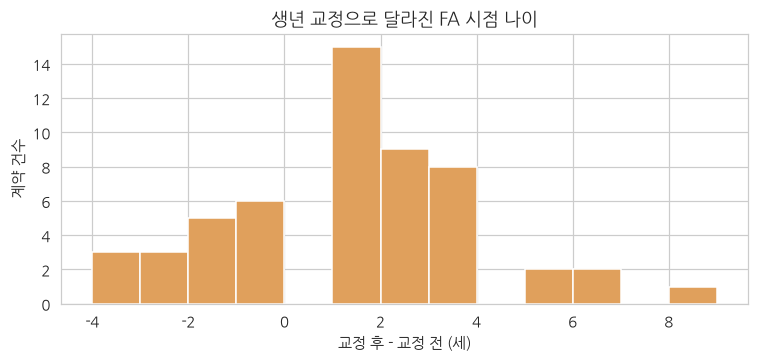

In [2]:
fa_old = pd.read_csv(DATA / "fa_contracts_v3.csv")
fa_new = pd.read_csv(DATA / "fa_contracts_v4.csv")

merged = fa_old.merge(fa_new, on=["player_name", "fa_year"], suffixes=("_old", "_new"))
merged["나이차"] = merged["age_at_fa_new"] - merged["age_at_fa_old"]
changed = merged[merged["나이차"] != 0]

print(f"대조 {len(merged)}건 중 나이가 바뀐 계약 {len(changed)}건")
if len(changed):
    print(f"최대 차이 {changed['나이차'].abs().max():.0f}세")
    display(changed.reindex(changed["나이차"].abs().sort_values(ascending=False).index)[
        ["player_name", "fa_year", "age_at_fa_old", "age_at_fa_new", "나이차"]].head())

    fig, ax = plt.subplots(figsize=(7, 3.4))
    bins = range(int(changed["나이차"].min()), int(changed["나이차"].max()) + 2)
    ax.hist(changed["나이차"], bins=bins, color="#e0a05c", edgecolor="white")
    ax.set_title("생년 교정으로 달라진 FA 시점 나이")
    ax.set_xlabel("교정 후 - 교정 전 (세)"); ax.set_ylabel("계약 건수")
    plt.tight_layout()
    plt.savefig(CHARTS / "02_age_correction.png", bbox_inches="tight")
    plt.show()

## 2. 학습셋 v8 로드

3년 집계는 `scripts/build_training_v8.py`가 만든다.
FA 직전 3시즌을 평균·합으로 접고, 부상 등으로 시즌이 비면 있는 시즌만 쓴다.
여기서는 만들어진 결과를 확인한다.

In [3]:
hitters = pd.read_csv(DATA / "hitter_training_v8.csv")
pitchers = pd.read_csv(DATA / "pitcher_training_v8.csv")

print(f"타자 {hitters.shape[0]}명 / {hitters.shape[1]}컬럼")
print(f"투수 {pitchers.shape[0]}명 / {pitchers.shape[1]}컬럼")
display(hitters[["player_name", "fa_year", "age_at_fa", "war_3yr_sum",
                 "ops_3yr_avg", "star_score", "annual_avg_salary"]].head())

타자 93명 / 47컬럼
투수 46명 / 47컬럼


,player_name,fa_year,age_at_fa,war_3yr_sum,ops_3yr_avg,star_score,annual_avg_salary
0,민병헌,2018,31,9.42,0.842242,6,20.00
1,황재균,2018,31,0.00,0.898949,4,22.00
2,김현수,2018,30,0.00,0.908664,18,28.75
3,정근우,2018,36,9.15,0.857741,15,11.67
4,손아섭,2018,32,18.84,0.901093,23,24.50


## 3. 스타성 피처

`national_team`, `mvp_count`, `golden_glove_count`를 합쳐 `star_score`를 만든다.
이 값들은 예전에 **출처 없이 손으로 적혀 있었고 상당수가 사실과 달랐다** (TS-004).
지금은 위키백과의 연도별 수상자 명단과 참가 선수 분류에서 자동으로 만든다 (TS-010).

> 아래 '대회별 등재 인원'은 실제 엔트리 수가 아니다.
> `kbo_awards.csv`는 (선수, 연도, 수상종류)로 중복을 지운다.
> 한 해에 두 대회를 뛴 선수는 한 번만 남는다 — 국가대표 **경력 연도** 수를
> 세는 것이 목적이라 같은 해를 두 번 세면 안 되기 때문이다.
> 그래서 2023 APBC는 엔트리 26명이지만 5명이 같은 해 WBC와 겹쳐 21로 보인다.

수상 기록 895 건


,건수
award,
GG,440
MVP,39
NT,416


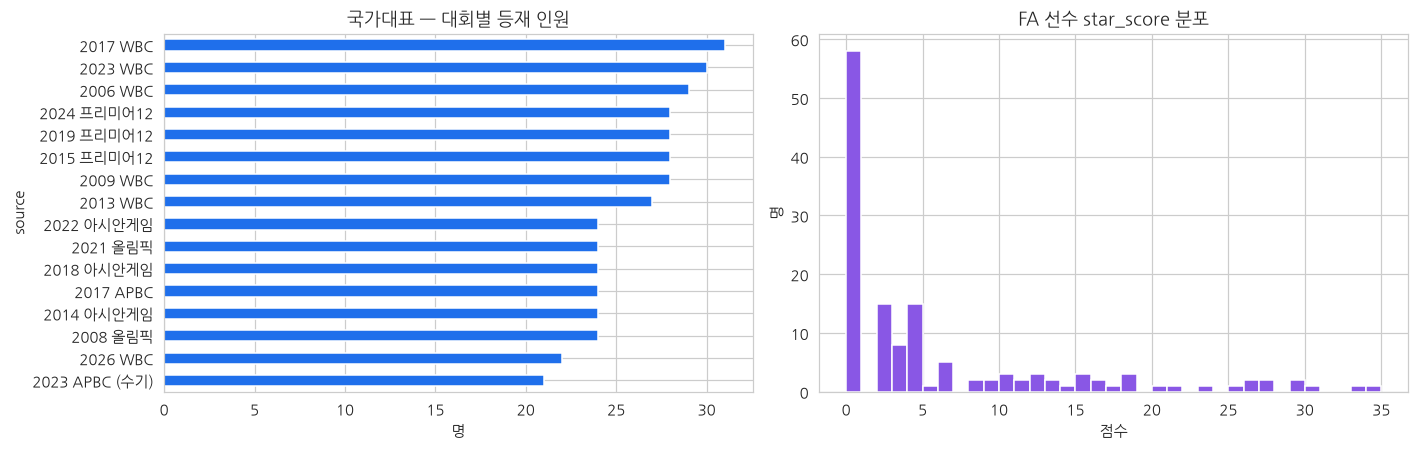

수상 이력이 전혀 없는 FA 선수 58명 / 139명


In [4]:
awards = pd.read_csv(DATA / "kbo_awards.csv")
print("수상 기록", len(awards), "건")
display(awards.groupby("award").size().to_frame("건수"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

nt = awards[awards.award == "NT"].groupby("source").size().sort_values()
nt.plot(kind="barh", ax=axes[0], color="#1f6feb")
axes[0].set_title("국가대표 — 대회별 등재 인원"); axes[0].set_xlabel("명")

star = pd.concat([hitters["star_score"], pitchers["star_score"]])
axes[1].hist(star, bins=range(0, int(star.max()) + 2), color="#8957e5", edgecolor="white")
axes[1].set_title("FA 선수 star_score 분포"); axes[1].set_xlabel("점수"); axes[1].set_ylabel("명")

plt.tight_layout()
plt.savefig(CHARTS / "02_star_features.png", bbox_inches="tight")
plt.show()

print(f"수상 이력이 전혀 없는 FA 선수 {(star == 0).sum()}명 / {len(star)}명")

## 4. 범주형 인코딩 — 투수 역할

투수는 선발(SP)·셋업(SU)·마무리(CL)의 가치 기준이 다르다.
세이브가 많은 마무리와 이닝이 많은 선발을 같은 잣대로 보면 안 된다.

역할별로 **모델을 3개 만들지 않고 피처 하나로 넣는다.**
KBO FA 투수는 표본이 46명뿐이라 3분할하면 한 덩어리가 15명 안팎이 되어
모델이 패턴을 못 잡는다.

In [5]:
from sklearn.preprocessing import LabelEncoder

print(pitchers["pitcher_role"].value_counts().to_string())

# 방법 1) 라벨 인코딩 — 값 하나로 압축된다. 트리 모델은 이걸로 충분하다.
encoder = LabelEncoder()
role_encoded = encoder.fit_transform(pitchers["pitcher_role"])
print("\n라벨 인코딩:", dict(zip(encoder.classes_,
                              encoder.transform(encoder.classes_).tolist())))

# 방법 2) 원핫 인코딩 — 순서가 없는 범주라 선형 모델에는 이쪽이 맞다.
onehot = pd.get_dummies(pitchers["pitcher_role"], prefix="role", drop_first=True)
display(onehot.head())

print("라벨 인코딩은 없는 순서(0 < 1 < 2)를 만든다.")
print("트리 모델은 분기로 나누므로 상관없지만, 선형 모델에는 원핫이 맞다.")

pitcher_role
RP    19
SP    17
CL     6
SU     4

라벨 인코딩: {'CL': 0, 'RP': 1, 'SP': 2, 'SU': 3}


,role_RP,role_SP,role_SU
0,False,True,False
1,True,False,False
2,True,False,False
3,True,False,False
4,False,True,False


라벨 인코딩은 없는 순서(0 < 1 < 2)를 만든다.
트리 모델은 분기로 나누므로 상관없지만, 선형 모델에는 원핫이 맞다.


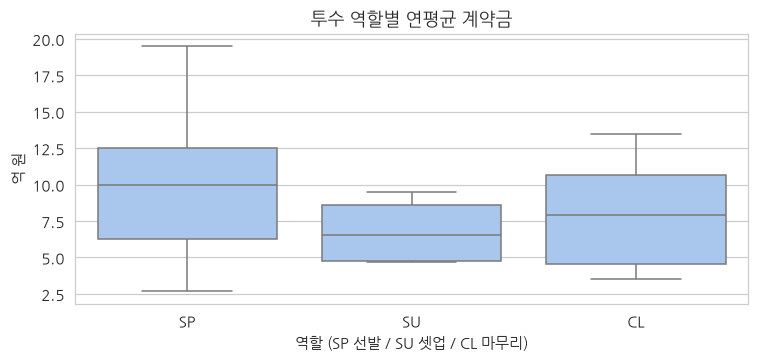

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
order = [r for r in ["SP", "SU", "CL"] if r in set(pitchers["pitcher_role"])]
sns.boxplot(data=pitchers, x="pitcher_role", y="annual_avg_salary",
            order=order, ax=ax, color="#9ec5f7")
ax.set_title("투수 역할별 연평균 계약금")
ax.set_xlabel("역할 (SP 선발 / SU 셋업 / CL 마무리)"); ax.set_ylabel("억 원")
plt.tight_layout()
plt.savefig(CHARTS / "02_pitcher_role.png", bbox_inches="tight")
plt.show()

## 5. 리그 대비 백분위

OPS .850은 타고투저 해에는 평범하고 투고타저 해에는 최상위다.
그래서 원래 스탯과 함께 **그 해 리그에서 몇 %인지**를 같이 넣는다.
전체 기준과 포지션 기준 두 가지를 만든다.

In [7]:
from src.features import HITTER_PCT_COLS, PITCHER_PCT_COLS, add_percentile_ranks

print("타자 백분위 대상:", HITTER_PCT_COLS)
print("투수 백분위 대상:", PITCHER_PCT_COLS)

hitters_eng = add_percentile_ranks(hitters.copy(), HITTER_PCT_COLS, "position")
pitchers_eng = add_percentile_ranks(pitchers.copy(), PITCHER_PCT_COLS, "pitcher_role")

added = [c for c in hitters_eng.columns if c not in hitters.columns]
print(f"\n타자에 늘어난 컬럼 {len(added)}개")
display(hitters_eng[["player_name", "war_3yr_sum",
                     "war_3yr_sum_all_pct", "war_3yr_sum_pos_pct"]].head())

타자 백분위 대상: ['war_3yr_avg', 'war_3yr_sum', 'ops_3yr_avg', 'wrc_plus_3yr_avg', 'hr_3yr_avg', 'rbi_3yr_avg', 'woba_3yr_avg']
투수 백분위 대상: ['war_3yr_sum', 'era_3yr_avg', 'innings_3yr_avg']

타자에 늘어난 컬럼 14개


,player_name,war_3yr_sum,war_3yr_sum_all_pct,war_3yr_sum_pos_pct
0,민병헌,9.42,0.752688,0.65625
1,황재균,0.00,0.091398,0.12500
2,김현수,0.00,0.091398,0.06250
3,정근우,9.15,0.731183,0.62500
4,손아섭,18.84,1.000000,1.00000


## 6. 데이터 누수 컬럼 제외

정답을 간접적으로 흘리는 컬럼은 반드시 빼야 한다.
`total_contract_amount`(총액)와 `contract_years`(계약 연수)는
나누면 바로 타깃이 나온다. 넣으면 지표가 치솟지만 아무 쓸모가 없다.
실제 서비스에서는 **계약 전에** 예측해야 하므로 이 값들을 알 수 없다.

In [8]:
EXCLUDED = {
    "annual_avg_salary",       # 타깃 그 자체
    "total_contract_amount",   # 타깃 x 계약연수
    "contract_years",          # 타깃과 총액을 잇는 값
    "player_name", "player_id", "team", "position", "pitcher_role", "seasons_used",
}

def feature_columns(frame):
    return [c for c in frame.columns
            if c not in EXCLUDED and pd.api.types.is_numeric_dtype(frame[c])]

h_cols = feature_columns(hitters_eng)
p_cols = feature_columns(pitchers_eng)
print(f"타자 모델 입력 피처 {len(h_cols)}개")
print(f"투수 모델 입력 피처 {len(p_cols)}개")
print("\n제외한 컬럼:", sorted(EXCLUDED & set(hitters_eng.columns)))

타자 모델 입력 피처 55개
투수 모델 입력 피처 47개

제외한 컬럼: ['annual_avg_salary', 'player_id', 'player_name', 'position', 'seasons_used', 'team']


## 정리

| 단계 | 한 일 |
|---|---|
| 생년 교정 | FA 원본 생년 오류를 고쳐 나이 피처 오염 제거 (TS-002) |
| 3년 집계 | FA 직전 3시즌을 한 행으로 |
| 스타성 | 위키백과에서 자동 수집한 수상·국가대표 이력 (TS-004·TS-010) |
| 인코딩 | 투수 역할을 라벨/원핫으로 — 별도 모델 3개 대신 피처 하나 |
| 백분위 | 같은 스탯도 그 해 리그 기준으로 다시 |
| 누수 제거 | 총액·계약연수 제외 |

다음: `03_eda.ipynb` — 만들어진 피처와 타깃의 관계를 본다.